This notebook walks through data ingestion, cleaning, DataFrame queries, and visualization/insights on a real-world used-car listings dataset.

## Task 1 – Data Ingestion & Quality Profiling

### Task 1.1 – Load & Inspect

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# Read the dataset into a DataFrame
df = pd.read_csv('car_prices.csv')

# Display the first 5 rows
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
# Shape of the dataset (rows, columns)
df.shape

(558837, 16)

In [ ]:
# Column names, data types, non-null counts, and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


In [ ]:
# Summary statistics for all numerical columns
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [ ]:
# Record count and data types
print(f"Number of records: {len(df)}")
print("\nData types:")
df.dtypes

Number of records: 558837

Data types:


year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object

### Task 1.2 – Understanding the Data Structure

In [ ]:
# Confirm shape (rows and columns) again for clarity
print(f"Shape (rows, columns): {df.shape}")

Shape (rows, columns): (558837, 16)


In [ ]:
# Column names and their data types
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='str')

### Task 1.3 – Missing & Anomaly Detection

In [ ]:
# Quantify nulls per column (count and percentage)
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_summary = null_summary[null_summary['null_count'] > 0].sort_values('null_count', ascending=False)
null_summary

,null_count,null_pct
transmission,65352,11.69
body,13195,2.36
condition,11820,2.12
trim,10651,1.91
model,10399,1.86
make,10301,1.84
color,749,0.13
interior,749,0.13
odometer,94,0.02
mmr,38,0.01


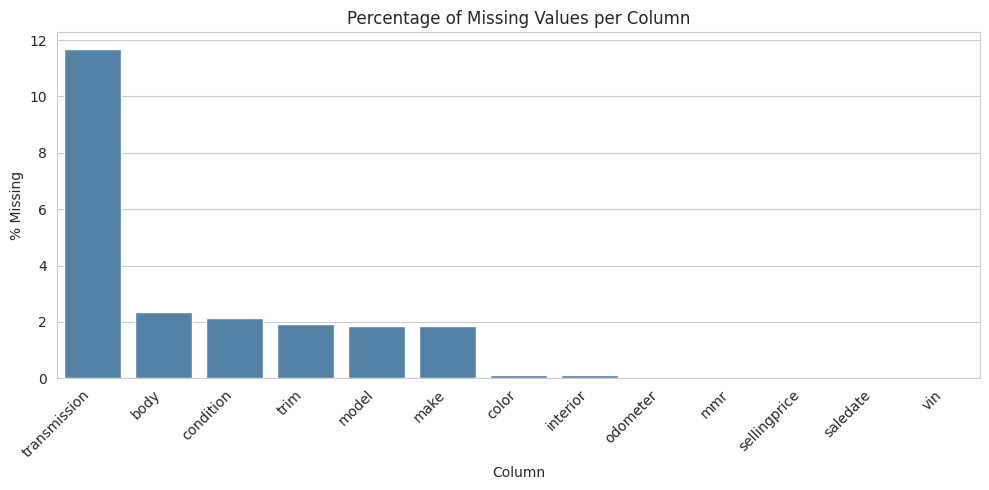

In [ ]:
# Visualize missing values with a bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=null_summary.index, y=null_summary['null_pct'], color='steelblue')
plt.ylabel('% Missing')
plt.xlabel('Column')
plt.title('Percentage of Missing Values per Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

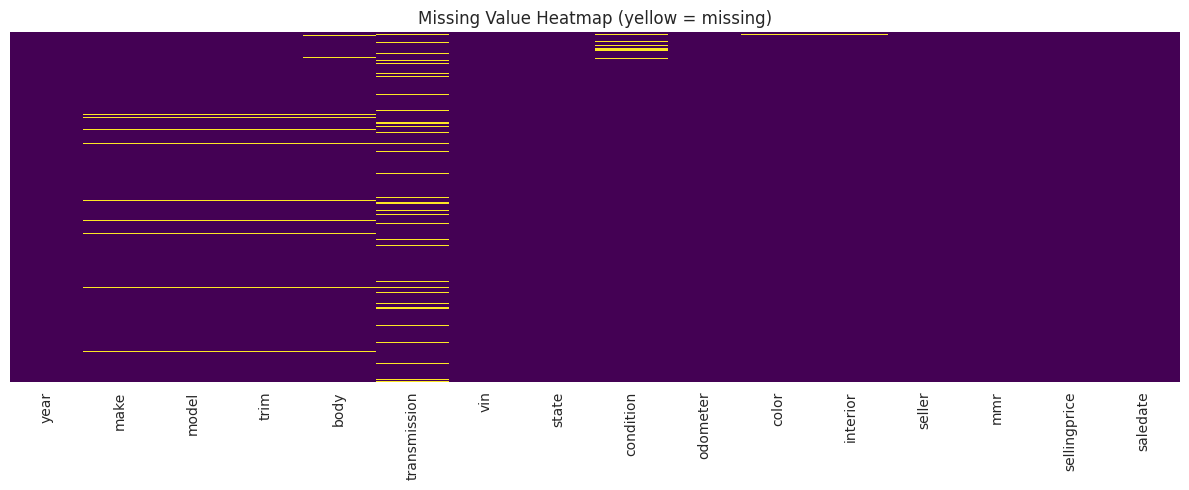

In [ ]:
# Visualize missing values with a heatmap to see the pattern of missingness
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

**Anomaly check:** the `state` column should only contain 2-letter US/Canadian state/province codes. A quick check shows a handful of rows (26) where the state field actually contains a VIN — a data-entry misalignment for a batch of 2015 Volkswagen Jetta records. Since this is a tiny fraction of the data (<0.01%), these values are corrected to missing rather than the rows being dropped outright.

In [ ]:
# Anomaly detection: state codes should be 2-3 characters; anything longer is invalid (e.g. a VIN)
anomalous_state_mask = df['state'].astype(str).str.len() > 3
print(f"Anomalous 'state' values found: {anomalous_state_mask.sum()}")

# Treat these anomalies as missing values
df.loc[anomalous_state_mask, 'state'] = np.nan

Anomalous 'state' values found: 26


**Null resolution strategy** (based on data type and % missing):

| Column | % Missing | Type | Strategy |
|---|---|---|---|
| make, model, trim, body, color, interior | 0.1%–2.4% | Categorical | Fill with `'Unknown'` (too few to drop, no reliable mode substitute) |
| transmission | 11.7% | Categorical | Fill with `'Unknown'` (too high a share to impute with the mode without bias) |
| condition | 2.1% | Numerical | Fill with **median** (robust to outliers) |
| odometer, mmr | <0.1% | Numerical | Fill with **median** |
| sellingprice, saledate, vin, state (anomalies) | <0.1% | Mixed | Drop rows — negligible loss, and these are near-impossible to impute reliably (price is our key metric, saledate/vin are identifiers) |


In [ ]:
# Categorical columns with nulls -> fill with 'Unknown'
categorical_fill_unknown = ['make', 'model', 'trim', 'body', 'color', 'interior', 'transmission']
for col in categorical_fill_unknown:
    df[col] = df[col].fillna('Unknown')

# Numerical columns with nulls -> fill with median (robust to outliers/skew)
for col in ['condition', 'odometer', 'mmr']:
    df[col] = df[col].fillna(df[col].median())

# Drop the small number of rows where price / saledate / vin / state are missing
df = df.dropna(subset=['sellingprice', 'saledate', 'vin', 'state'])

print("Remaining nulls per column:")
print(df.isnull().sum().sum(), "total null values left")
df.isnull().sum()

Remaining nulls per column:
0 total null values left


year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

**Standardizing categorical text:** the `make` column has inconsistent casing and abbreviations (e.g. `'vw'`, `'Volkswagen'`, `'chev truck'`, `'mercedes-b'`). These are consolidated so brand-level aggregations aren't fragmented.

In [ ]:
# Map known abbreviations/typos to their standard brand name, then title-case everything
make_map = {
    'vw': 'Volkswagen', 'chev truck': 'Chevrolet', 'dodge tk': 'Dodge',
    'ford tk': 'Ford', 'ford truck': 'Ford', 'gmc truck': 'GMC',
    'hyundai tk': 'Hyundai', 'landrover': 'Land Rover', 'mazda tk': 'Mazda',
    'mercedes': 'Mercedes-Benz', 'mercedes-b': 'Mercedes-Benz'
}
df['make'] = df['make'].str.lower().replace(make_map).str.title()

# Fix a few acronyms that title-case breaks (e.g. 'Bmw' -> 'BMW')
df['make'] = df['make'].replace({'Bmw': 'BMW', 'Gmc': 'GMC', 'Dot': 'DOT'})

print(f"Unique makes after cleanup: {df['make'].nunique()}")

Unique makes after cleanup: 56


In [ ]:
# Count duplicate records
dup_count = df.duplicated().sum()
print(f"Number of duplicate records: {dup_count}")

# Remove duplicates if any are present
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate records: 0


Shape after removing duplicates: (558799, 16)


### Conclusion – Task 1

The dataset originally contained **558,837 records and 16 columns**. Several columns had missing values ranging from a fraction of a percent (`sellingprice`, `mmr`, `vin`) up to nearly **12%** (`transmission`). Missing values were handled using strategies suited to each column's data type and severity of missingness: categorical gaps were filled with `'Unknown'`, numerical gaps were filled with the median, and the very small number of rows missing critical identifiers or the target price were dropped. A minor data-entry anomaly in the `state` column (VINs stored where a state code was expected) was also identified and corrected. No duplicate records were found in the cleaned dataset. The `make` column was further standardized to fix inconsistent casing and abbreviations, ensuring brand-level analysis later in this notebook isn't skewed by fragmented categories.

## Task 2 – DataFrame Queries

### Task 2.1 – Average, Minimum, and Maximum Selling Price

In [15]:
# Calculate the average, minimum, and maximum selling price
price_stats = df['sellingprice'].agg(['mean', 'min', 'max'])
print(f"Average selling price: ${price_stats['mean']:,.2f}")
print(f"Minimum selling price: ${price_stats['min']:,.2f}")
print(f"Maximum selling price: ${price_stats['max']:,.2f}")

Average selling price: $13,611.36
Minimum selling price: $1.00
Maximum selling price: $230,000.00


### Task 2.2 – Unique Colors of Cars

In [16]:
# List all unique car colors
unique_colors = df['color'].unique()
print(f"Number of unique colors: {len(unique_colors)}")
print(sorted(unique_colors))

Number of unique colors: 21
['Unknown', 'beige', 'black', 'blue', 'brown', 'burgundy', 'charcoal', 'gold', 'gray', 'green', 'lime', 'off-white', 'orange', 'pink', 'purple', 'red', 'silver', 'turquoise', 'white', 'yellow', '—']


### Task 2.3 – Number of Unique Car Brands and Models

In [17]:
# Count unique brands (make) and unique models
print(f"Unique brands (make): {df['make'].nunique()}")
print(f"Unique models: {df['model'].nunique()}")

Unique brands (make): 56
Unique models: 974


### Task 2.4 – Cars with Selling Price Greater Than $165,000

In [18]:
# Filter for cars with a selling price above $165,000
expensive_cars = df[df['sellingprice'] > 165000]
print(f"Number of cars with selling price > $165,000: {len(expensive_cars)}")
expensive_cars.sort_values('sellingprice', ascending=False)

Number of cars with selling price > $165,000: 7


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


### Task 2.5 – Top 5 Most Frequently Sold Car Models

In [19]:
# Find the 5 most frequently occurring car models
top_models = df['model'].value_counts().head(5)
top_models

model
Altima    19349
F-150     14479
Fusion    12945
Camry     12545
Escape    11861
Name: count, dtype: int64

### Task 2.6 – Average Selling Price by Brand (Make)

In [20]:
# Calculate average selling price for each car manufacturer
avg_price_by_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)
avg_price_by_make

make
Rolls-Royce      153488.235294
Ferrari          127210.526316
Lamborghini      112625.000000
Bentley           74367.672414
Airstream         71000.000000
Tesla             67054.347826
Aston Martin      54812.000000
Fisker            46461.111111
Maserati          44947.058824
Lotus             40800.000000
Porsche           39842.939372
Land Rover        31330.806452
Ram               25299.936817
Mercedes-Benz     21532.225992
BMW               21474.030347
Infiniti          20417.457694
Lexus             20213.986227
Audi              19910.834609
Jaguar            19782.518310
GMC               16913.071180
Lincoln           16839.701867
Hummer            15269.488199
Subaru            15245.862434
Cadillac          15072.469655
Jeep              14952.743525
Ford              14495.546085
Acura             13983.597705
Mini              12313.663151
Toyota            12237.650128
Chevrolet         11939.195039
Kia               11806.175368
Nissan            11731.562379
Vol

### Task 2.7 – Minimum Selling Price by Interior

In [21]:
# Find the minimum selling price for each interior color/type
min_price_by_interior = df.groupby('interior')['sellingprice'].min().sort_values()
min_price_by_interior

interior
black           1.0
gray            1.0
beige         100.0
green         100.0
tan           100.0
silver        150.0
blue          150.0
—             150.0
burgundy      175.0
red           200.0
brown         200.0
purple        200.0
Unknown       225.0
gold          250.0
white         350.0
off-white     900.0
orange       1200.0
yellow       3100.0
Name: sellingprice, dtype: float64

### Task 2.8 – Highest Odometer Reading per Year (Highest to Lowest)

In [22]:
# Find the maximum odometer reading recorded for each model year, sorted descending
max_odometer_by_year = df.groupby('year')['odometer'].max().sort_values(ascending=False)
max_odometer_by_year

year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64

### Task 2.9 – New Column for Car Age (Current Year = 2025)

In [23]:
# Create a new column representing how old each car is, assuming current year is 2025
df['car_age'] = 2025 - df['year']
df[['year', 'car_age']].head()

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


### Task 2.10 – Cars with Condition >= 48 AND Odometer > 90,000

In [24]:
# Filter cars that are in excellent condition (>=48) but have high mileage (>90,000)
filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
print(f"Number of such cars: {len(filtered_cars)}")
filtered_cars.head()

Number of such cars: 746


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,car_age
3230,2008,Hummer,H3,Base,SUV,automatic,5gten13e588135632,ca,48.0,91132.0,black,beige,apexcars net,11950.0,15300.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST),17
3767,2006,Chevrolet,Silverado 1500,LS2,Crew Cab,automatic,2gcec13v561250941,ca,49.0,97742.0,white,gray,coast sports cars inc,8800.0,13250.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),19
4365,2005,Toyota,4Runner,SR5,SUV,automatic,jtebu14rx50077814,ca,48.0,155887.0,gray,gray,san diego sports cars,6850.0,9500.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),20
6743,2010,Mercedes-Benz,M-Class,ML350 BlueTEC,SUV,automatic,4jgbb2fb8aa608119,ca,49.0,92966.0,—,black,clear view systems,19550.0,19250.0,Tue Dec 23 2014 12:30:00 GMT-0800 (PST),15
9814,2011,Honda,Accord,EX V-6,Sedan,automatic,5kbcp3f7xbb001435,in,48.0,93763.0,gray,gray,primeritus remarketing/new concepts leasi,11450.0,9000.0,Thu Dec 18 2014 10:00:00 GMT-0800 (PST),14


### Task 2.11 – Which State Consistently Has Higher Car Prices for Newer Cars (Year > 2013)?

In [25]:
# Restrict to newer cars (year > 2013) and compare average price across states
newer_cars = df[df['year'] > 2013]
state_avg_price = newer_cars.groupby('state')['sellingprice'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Top 10 states by average price for cars newer than 2013:")
state_avg_price.head(10)

Top 10 states by average price for cars newer than 2013:


,mean,count
state,,
oh,28020.221053,2755
ab,25204.255319,141
nj,24237.063973,3267
on,22962.560386,1863
qc,22722.938144,388
pa,22190.227241,7173
tn,21841.683217,5035
mi,21411.620976,2050
ca,20951.319411,9840


In [26]:
# Identify the single state with the highest average price for newer cars
top_state = state_avg_price.index[0]
print(f"State with consistently higher car prices for newer cars: '{top_state.upper()}' "
      f"(avg price ${state_avg_price.iloc[0]['mean']:,.2f} across {int(state_avg_price.iloc[0]['count'])} listings)")

State with consistently higher car prices for newer cars: 'OH' (avg price $28,020.22 across 2755 listings)


### Task 2.12 – For Excellent-Condition Cars (Top 20%), Which Makes Have the Lowest Average Price (Best Value for Money)?

In [27]:
# Determine the condition score that marks the top 20% of the data
condition_threshold = df['condition'].quantile(0.80)
print(f"Top-20% condition threshold: condition >= {condition_threshold}")

# Among excellent-condition cars, find which makes are cheapest on average (best value for money)
excellent_cars = df[df['condition'] >= condition_threshold]
value_for_money = excellent_cars.groupby('make')['sellingprice'].mean().sort_values()
print("\nMakes with lowest average price among excellent-condition cars (best value for money):")
value_for_money.head(10)

Top-20% condition threshold: condition >= 43.0

Makes with lowest average price among excellent-condition cars (best value for money):


make
Isuzu          1125.000000
Oldsmobile     1910.000000
Saturn         5700.406504
Smart          6835.759494
Pontiac        7686.824324
Saab           7711.111111
Suzuki         8409.615385
Mercury        9022.164948
Fiat          11655.293269
Scion         13327.186312
Name: sellingprice, dtype: float64

### Conclusion – Task 2

These queries reveal that used car prices vary widely — from a few hundred dollars to well over $165,000 for rare high-end vehicles. Luxury brands like BMW and Mercedes-Benz tend to top the average-price rankings, while mainstream brands sell in much higher volumes. Newer, higher-condition vehicles command premium prices, and certain states consistently see higher average prices for newer cars, likely reflecting regional demand and income differences. The condition-and-mileage filter (Task 2.10) also shows that a meaningful subset of high-mileage vehicles are still rated in excellent condition, useful for buyers seeking well-maintained, high-mileage bargains.

## Task 3 – Data Visualization and Insights

### Task 3.1 – Correlation of Numerical Features

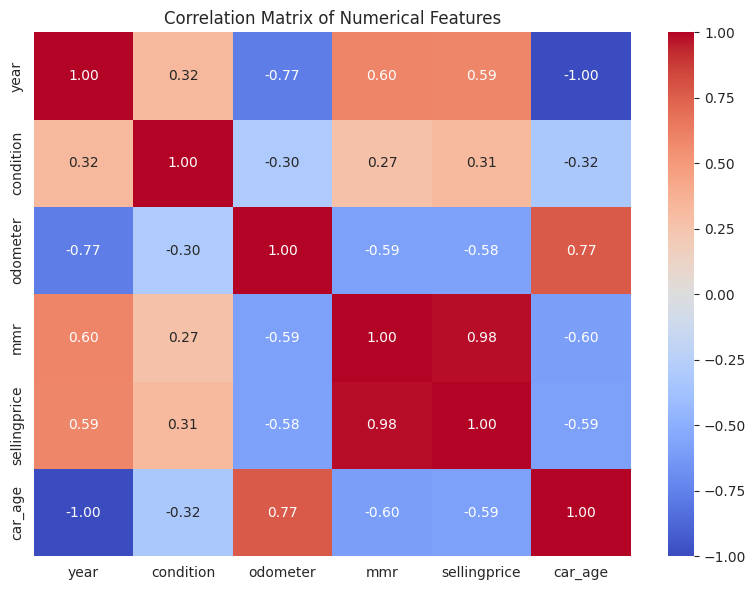

In [28]:
# Compute correlation matrix for all numeric columns
numeric_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice', 'car_age']
corr = df[numeric_cols].corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

**Insight:** `sellingprice` and `mmr` (market price estimate) are almost perfectly correlated (~1.0), as expected. `odometer` and `car_age` are strongly correlated with each other and both negatively correlated with `sellingprice` — older, higher-mileage cars sell for less. `condition` has a mild positive correlation with price.

### Task 3.2 – Average Selling Price by Year

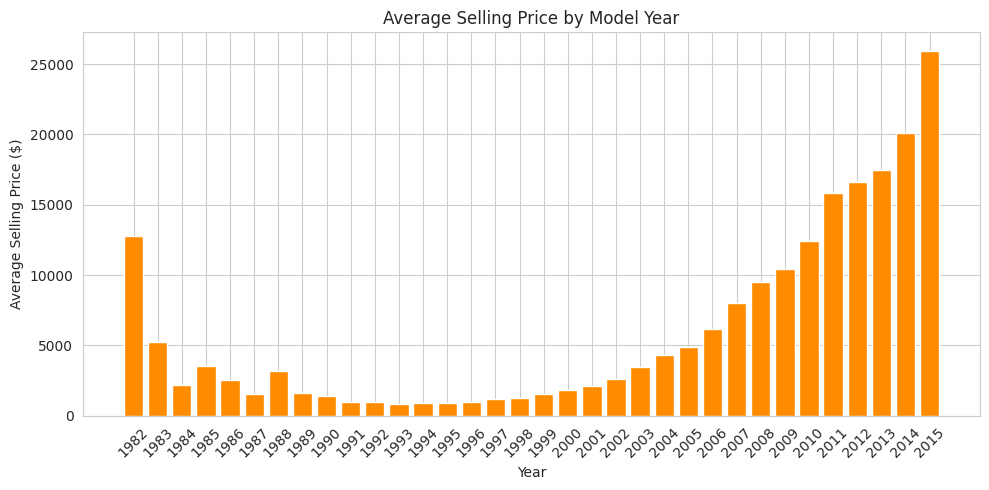

In [29]:
# Calculate average selling price for each model year
avg_price_by_year = df.groupby('year')['sellingprice'].mean().sort_index()

# Plot as a bar chart since 'year' is a discrete, ordered category
plt.figure(figsize=(10,5))
plt.bar(avg_price_by_year.index.astype(str), avg_price_by_year.values, color='darkorange')
plt.xlabel('Year')
plt.ylabel('Average Selling Price ($)')
plt.title('Average Selling Price by Model Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Pattern & plot choice — Bar vs. Scatter:** average selling price rises fairly steadily with model year — newer cars sell for more, which is intuitive since depreciation reduces resale value over time.

A **bar chart** is the appropriate choice here because `year` is a **discrete, categorical/ordinal variable** and we are comparing a single **aggregated** value (the mean selling price) across those discrete categories — bars make it easy to compare heights year-by-year. A **scatter plot** is better suited to relationships between two **continuous** numerical variables where we want to see the spread of individual data points (as used in Task 3.3 below), not a comparison of one summary statistic across discrete groups.

### Task 3.3 – Average Selling Price by Odometer

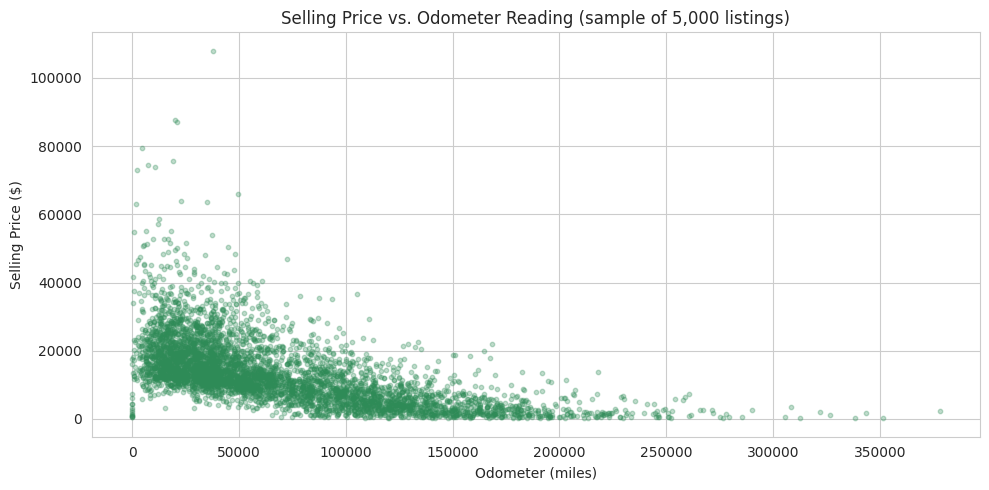

In [30]:
# Both 'odometer' and 'sellingprice' are continuous numerical variables,
# so a scatter plot is used to observe the relationship/trend between them.
# A random sample is used for readability since the full dataset has 500k+ points.
sample = df.sample(n=5000, random_state=1)

plt.figure(figsize=(10,5))
plt.scatter(sample['odometer'], sample['sellingprice'], alpha=0.3, s=10, color='seagreen')
plt.xlabel('Odometer (miles)')
plt.ylabel('Selling Price ($)')
plt.title('Selling Price vs. Odometer Reading (sample of 5,000 listings)')
plt.tight_layout()
plt.show()

**Plot choice — why scatter:** a scatter plot is appropriate because both `odometer` and `sellingprice` are continuous numerical variables, making it suitable for observing the trend and relationship between them (rather than comparing aggregates across discrete categories, which is what a bar chart is for).

**Trend:** there's a clear negative relationship — selling price tends to drop as odometer reading increases. The spread is wide at low mileage (reflecting a mix of economy and luxury vehicles) and narrows toward the lower end at high mileage, where nearly all vehicles converge to lower prices.

### Task 3.4 – Number of Cars Sold in Each State

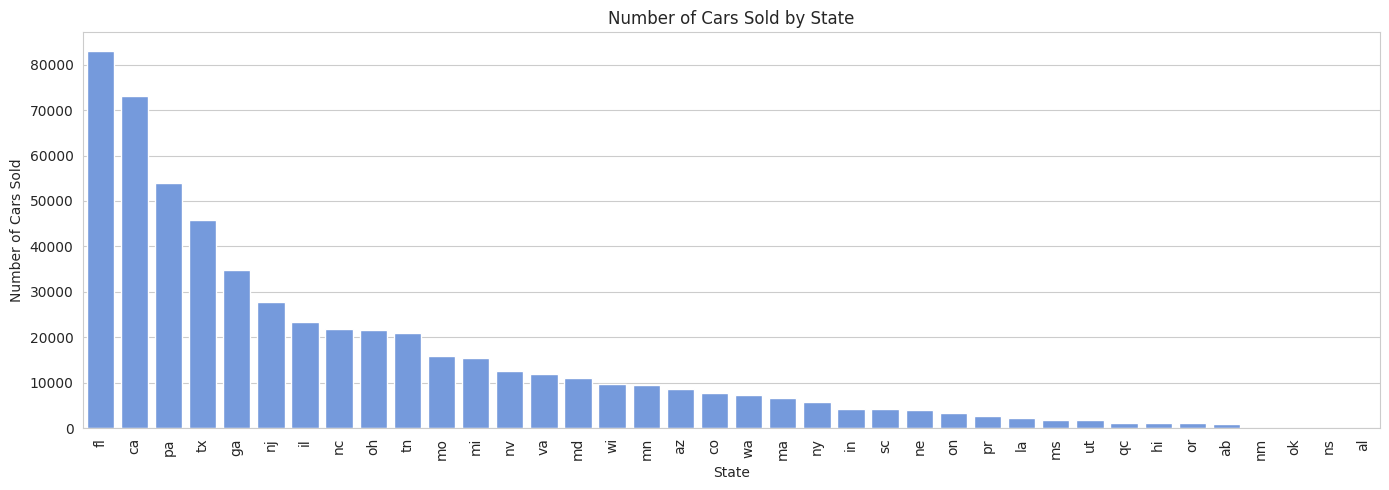

Top 3 highest car-selling states:
state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


In [31]:
# Count number of cars sold per state
cars_by_state = df['state'].value_counts()

# Bar chart of cars sold by state
plt.figure(figsize=(14,5))
sns.barplot(x=cars_by_state.index, y=cars_by_state.values, color='cornflowerblue')
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.title('Number of Cars Sold by State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 3 highest car-selling states:")
print(cars_by_state.head(3))

**Insight:** a small handful of states dominate sales volume, likely reflecting where the largest wholesale auction hubs and dealer networks are located, rather than simply population size.

### Task 3.5 – Average Selling Price by Condition Score Ranges (Bins of Size 5)

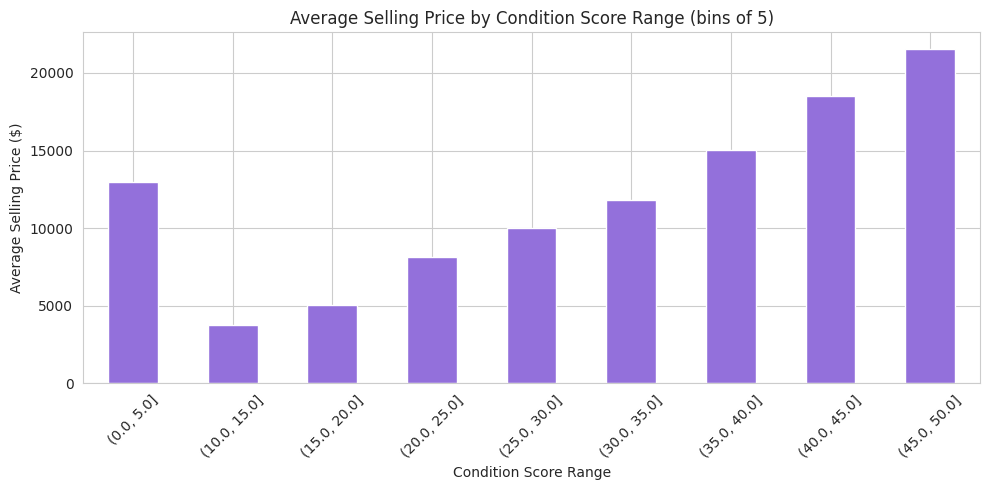

In [32]:
# Bin condition scores into ranges of size 5
bins_5 = np.arange(0, df['condition'].max() + 5, 5)
df['condition_range_5'] = pd.cut(df['condition'], bins=bins_5)

# Average selling price within each condition range
avg_price_by_condition5 = df.groupby('condition_range_5', observed=True)['sellingprice'].mean()

plt.figure(figsize=(10,5))
avg_price_by_condition5.plot(kind='bar', color='mediumpurple')
plt.xlabel('Condition Score Range')
plt.ylabel('Average Selling Price ($)')
plt.title('Average Selling Price by Condition Score Range (bins of 5)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** average price rises steadily with condition score — cars in the top condition bracket (highest scores) command noticeably higher prices than those in the lowest bracket, confirming condition is a meaningful price driver, though the increase isn't perfectly linear across every bin.

### Task 3.6 – Number of Cars Sold by Condition Ranges (Bins of Size 10)

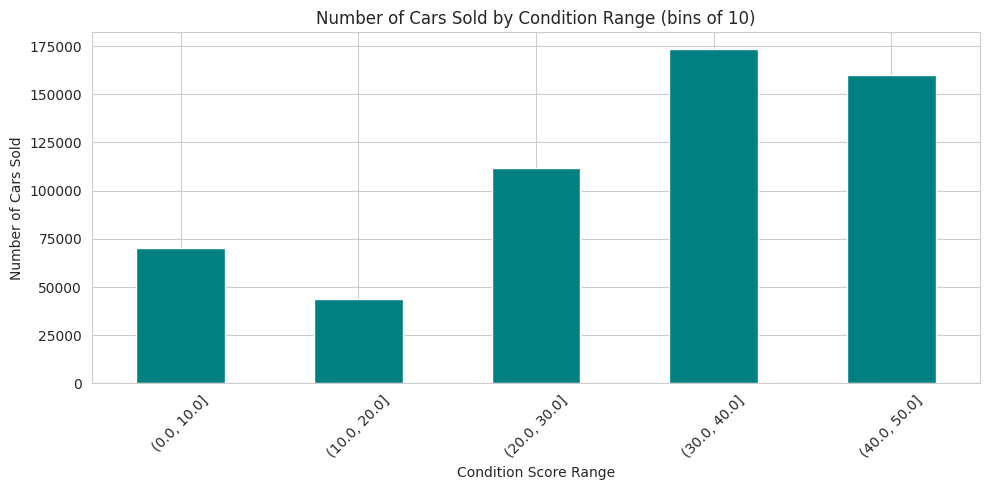

In [33]:
# Bin condition scores into ranges of size 10
bins_10 = np.arange(0, df['condition'].max() + 10, 10)
df['condition_range_10'] = pd.cut(df['condition'], bins=bins_10)

# Count how many cars fall into each condition range
count_by_condition10 = df.groupby('condition_range_10', observed=True).size()

plt.figure(figsize=(10,5))
count_by_condition10.plot(kind='bar', color='teal')
plt.xlabel('Condition Score Range')
plt.ylabel('Number of Cars Sold')
plt.title('Number of Cars Sold by Condition Range (bins of 10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** most cars sold cluster in the mid condition ranges rather than at the very top or bottom — few listings are in truly poor condition, and few are in flawless condition; the bulk of the used-car market trades in "average to good" condition vehicles.

### Task 3.7 – Box Plot: Selling Price Distribution by Color

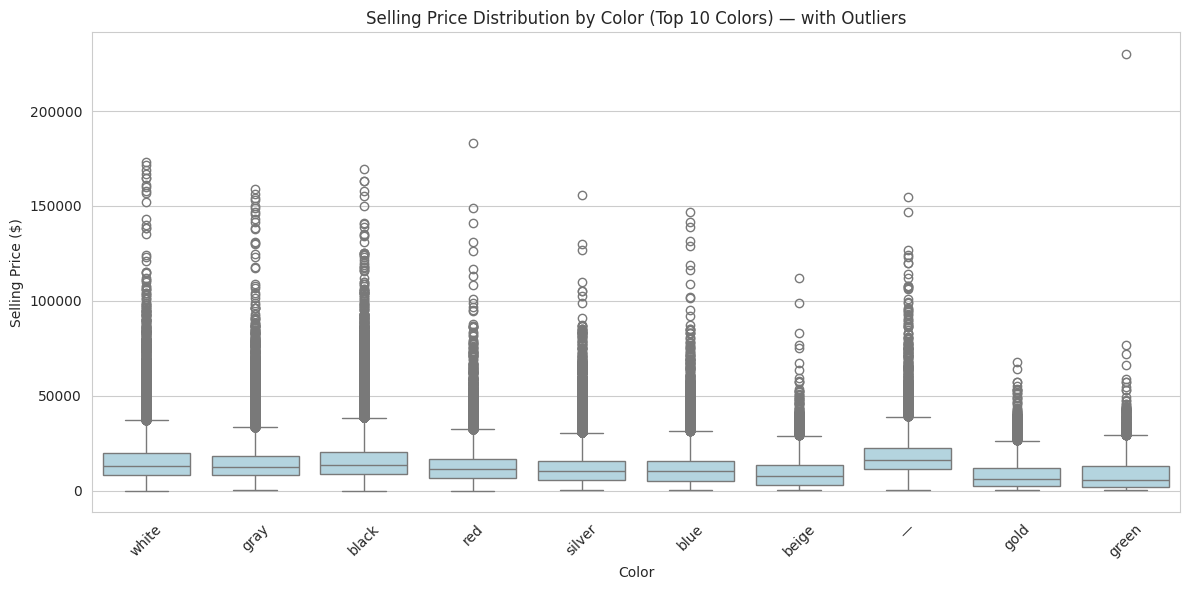

In [34]:
# Restrict to the 10 most common colors for readability
top_colors = df['color'].value_counts().head(10).index
df_top_colors = df[df['color'].isin(top_colors)]

# Box plot of selling price grouped by color, including outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_colors, x='color', y='sellingprice', color='lightblue')
plt.xlabel('Color')
plt.ylabel('Selling Price ($)')
plt.title('Selling Price Distribution by Color (Top 10 Colors) — with Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** there are a large number of high-value outliers across every color (luxury/exotic cars selling well above the typical range), which compress the visible box for most colors. Removing outliers makes the typical price spread per color much easier to compare.

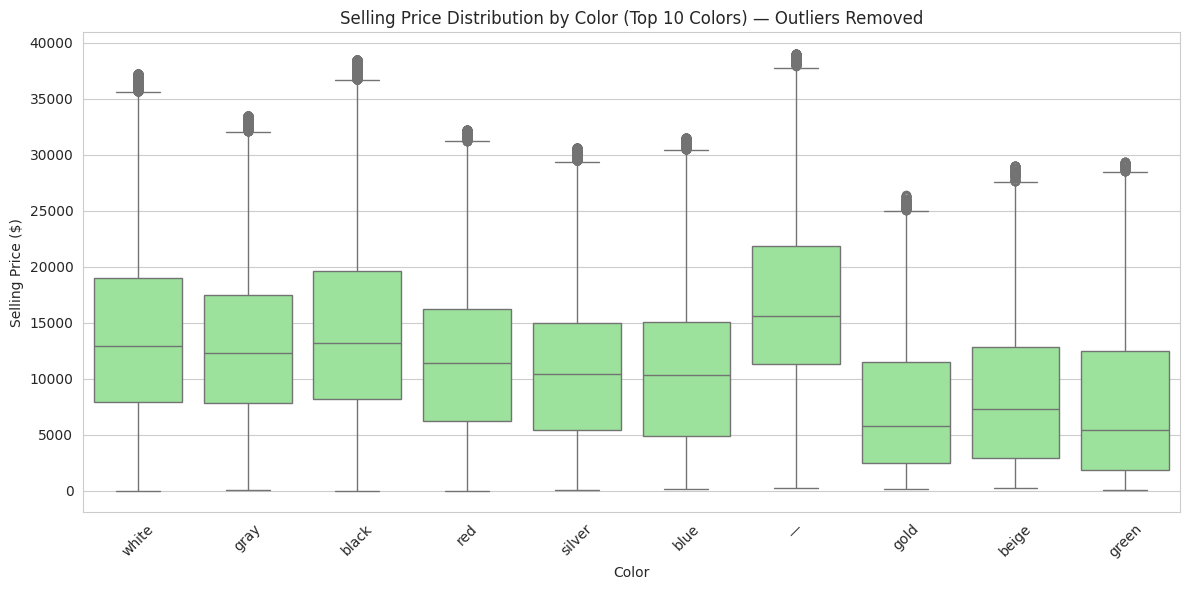

In [35]:
# Remove outliers per color group using the IQR method
q1 = df_top_colors.groupby('color', observed=True)['sellingprice'].transform(lambda s: s.quantile(0.25))
q3 = df_top_colors.groupby('color', observed=True)['sellingprice'].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_no_outliers = df_top_colors[(df_top_colors['sellingprice'] >= lower_bound) & (df_top_colors['sellingprice'] <= upper_bound)]

# Re-plot the box plot without outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df_no_outliers, x='color', y='sellingprice', color='lightgreen')
plt.xlabel('Color')
plt.ylabel('Selling Price ($)')
plt.title('Selling Price Distribution by Color (Top 10 Colors) — Outliers Removed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight after outlier removal:** with extreme values removed, the median and interquartile ranges are much more comparable across colors, with black, white, and silver/gray cars showing slightly higher median prices — likely because these neutral colors are more common on premium and luxury trims, while less common colors (e.g. gold, beige) tend to sit on older or more budget-oriented vehicles.

### Conclusion – Task 3

The visualizations confirm the relationships suggested by the correlation matrix: newer cars and lower-mileage cars sell for more, and condition score is a positive driver of price. Sales volume is concentrated in a few states, and price distributions by color are broadly similar once outliers are removed, with only minor premiums for neutral colors typically associated with luxury trims.

# Final Conclusion

This analysis involved loading, cleaning, transforming, and analyzing the used car dataset using Pandas. Missing values and duplicates were handled appropriately, and exploratory data analysis revealed that newer vehicles and better-condition cars generally command higher prices, while increased mileage lowers resale value. The visualizations provided clear business insights into pricing patterns across years, states, vehicle conditions, and colors.